In [1]:
%load_ext watermark
%watermark -a 'eli knaap'
%load_ext autoreload
%autoreload 2

import geopandas as gpd
from libpysal import examples

from esda import correlogram

Author: eli knaap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sac = gpd.read_file(examples.load_example("Sacramento1").get_path("sacramentot2.shp"))

In [3]:
sac = sac.to_crs(sac.estimate_utm_crs())  # now in meters)

In [4]:
correlogram?

In [5]:
from esda import G, Geary, Moran

In [6]:
# Create a liste of distances between 500 and 5000 (meters, here) in increments of 500

distances = [i + 500 for i in range(0, 5000, 500)]

In [7]:
distances

[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

In [8]:
prof = correlogram(sac.centroid, sac.HH_INC, distances, Moran)

In [9]:
prof.head()

,y,w,permutations,n,z,z2ss,EI,VI_norm,seI_norm,VI_rand,...,z_rand,p_norm,p_rand,sim,p_sim,EI_sim,seI_sim,VI_sim,z_sim,p_z_sim
500,"[52941, 51958, 32992, 54556, 50815, 60167, 490...",<libpysal.weights.distance.DistanceBand object...,999,403,"[0.27506115837390277, 0.21948138443207246, -0....",1.260604e+11,-0.002488,0.497534,0.705361,0.496239,...,0.086188,9.314058e-01,9.313166e-01,"[-0.16000777006309336, 0.35057087080076826, 1....",0.467,0.030311,0.740235,0.547948,0.037713,4.849582e-01
1000,"[52941, 51958, 32992, 54556, 50815, 60167, 490...",<libpysal.weights.distance.DistanceBand object...,999,403,"[0.27506115837390277, 0.21948138443207246, -0....",1.260604e+11,-0.002488,0.014259,0.119409,0.014221,...,4.147088,3.447621e-05,3.367309e-05,"[-0.15837501828903583, 0.16160116340628766, -0...",0.001,-0.003759,0.116280,0.013521,4.264085,1.003616e-05
1500,"[52941, 51958, 32992, 54556, 50815, 60167, 490...",<libpysal.weights.distance.DistanceBand object...,999,403,"[0.27506115837390277, 0.21948138443207246, -0....",1.260604e+11,-0.002488,0.004586,0.067719,0.004574,...,6.763620,1.430242e-11,1.345857e-11,"[-0.03211300536047097, -0.02421367694402564, -...",0.001,-0.003493,0.067958,0.004618,6.745910,7.603567e-12
2000,"[52941, 51958, 32992, 54556, 50815, 60167, 490...",<libpysal.weights.distance.DistanceBand object...,999,403,"[0.27506115837390277, 0.21948138443207246, -0....",1.260604e+11,-0.002488,0.002164,0.046515,0.002158,...,12.164298,5.846476e-34,4.815656e-34,"[-0.10012000185819878, 0.0322173415965063, -0....",0.001,-0.003062,0.046191,0.002134,12.245928,8.832224e-35
2500,"[52941, 51958, 32992, 54556, 50815, 60167, 490...",<libpysal.weights.distance.DistanceBand object...,999,403,"[0.27506115837390277, 0.21948138443207246, -0....",1.260604e+11,-0.002488,0.001481,0.038483,0.001477,...,13.102771,3.974924e-39,3.174519e-39,"[-0.04096550715030278, 0.027544312005584316, 0...",0.001,-0.002137,0.038358,0.001471,13.119279,1.276766e-39


Text(0, 0.5, "Moran's I")

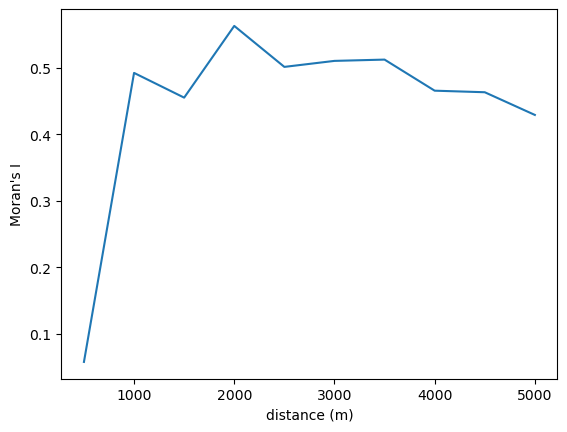

In [10]:
ax = prof.I.plot()
ax.set_xlabel("distance (m)")
ax.set_ylabel("Moran's I")

In [11]:
prof = correlogram(sac.centroid, sac.HH_INC, distances, statistic=Geary)

Text(0, 0.5, "Geary's C")

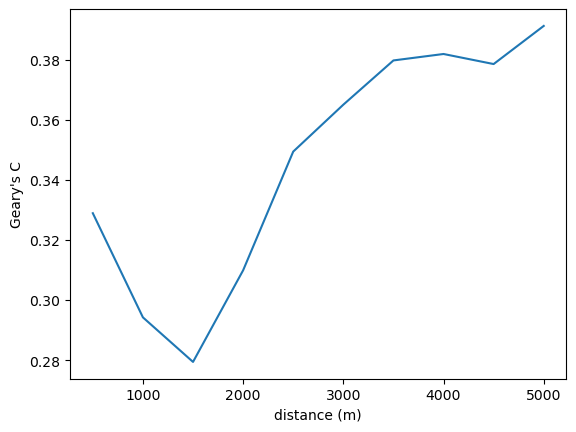

In [12]:
ax = prof.C.plot()
ax.set_xlabel("distance (m)")
ax.set_ylabel("Geary's C")

In [13]:
prof = correlogram(sac.centroid, sac.HH_INC, distances, statistic=G)

Text(0, 0.5, 'Getis-Ord G')

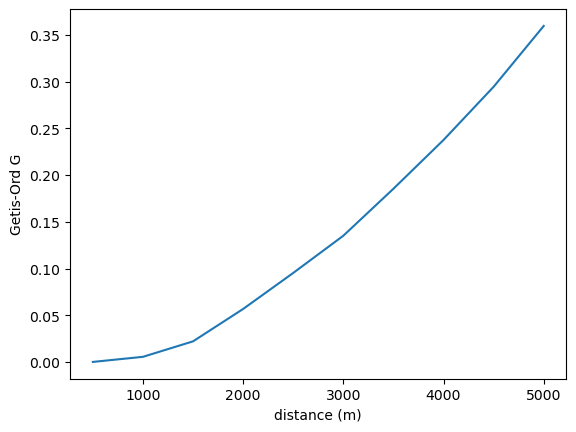

In [14]:
ax = prof.G.plot()
ax.set_xlabel("distance (m)")
ax.set_ylabel("Getis-Ord G")

Text(0, 0.5, 'Getis-Ord G')

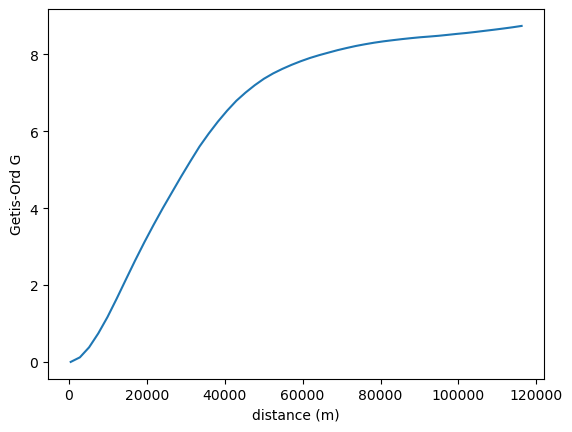

In [15]:
prof = correlogram(sac.centroid, sac.HH_INC, statistic=G)
ax = prof.G.plot()
ax.set_xlabel("distance (m)")
ax.set_ylabel("Getis-Ord G")

In [16]:
kdists = list(range(1, 50))

In [17]:
kcorr = correlogram(sac.centroid, sac.HH_INC, kdists, distance_type="knn")

Text(0, 0.5, "Moran's I")

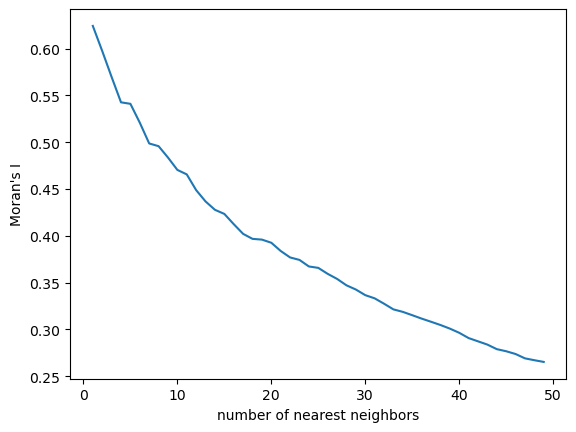

In [18]:
ax = kcorr.I.plot()
ax.set_xlabel("number of nearest neighbors")
ax.set_ylabel("Moran's I")

Text(0, 0.5, 'Correlation between pairs\napproximately this separation')

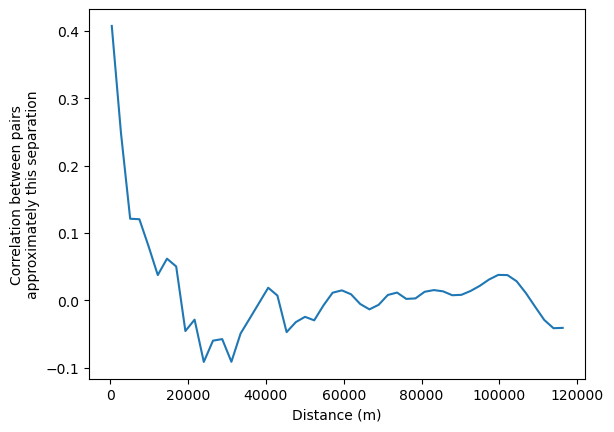

In [19]:
nonparametric = correlogram(sac.centroid, sac.HH_INC, statistic="lowess")
ax = nonparametric.lowess.plot()
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Correlation between pairs\napproximately this separation")